In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

In [4]:
mol = gto.M(
    atom=
    '''
    N   0.00000000,  0.00000000,  0.0000000
    N   1.11200000,  0.00000000,  0.0000000
    ''',
    # atom=
    # '''
    # O   0.00000000,  0.00000000,  0.00000000
    # H   0.75700000,  0.00000000,  0.58590000
    # H  -0.75700000,  0.00000000,  0.58590000
    # ''',
    basis="sto-3g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
solver.nroots = 3
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
e_fci = e_fci[0]
# s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
# print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))

SCF energy : -107.498967544584
FCI energy : -107.660206420048


step=   0  energy=-107.49888659  variance= 0.33451666  acc=0.000  ess= 521.0  ess_unique= 1.000  chain_uratio= 0.004  sample_uratio= 0.105  n_eval=1951.0
         times: backward= 0.5894 | forward= 0.3915 | graph= 0.0093 | reduction= 0.0032 | sampler= 0.0069 | total= 1.0004
step=  10  energy=-107.62809226  variance= 0.01313531  acc=0.060  ess= 439.5  ess_unique= 1.040  chain_uratio= 0.060  sample_uratio= 0.148  n_eval=2861.0
         times: backward= 0.0037 | forward= 0.0660 | graph= 0.0125 | reduction= 0.0027 | sampler= 0.0080 | total= 0.0930
step=  20  energy=-107.64496224  variance= 0.01264587  acc=0.125  ess= 361.3  ess_unique= 1.067  chain_uratio= 0.105  sample_uratio= 0.216  n_eval=3276.0
         times: backward= 0.0042 | forward= 0.0875 | graph= 0.0146 | reduction= 0.0039 | sampler= 0.0082 | total= 0.1183
step=  30  energy=-107.65231246  variance= 0.01932553  acc=0.139  ess= 280.6  ess_unique= 1.094  chain_uratio= 0.146  sample_uratio= 0.258  n_eval=3373.0
         times: backw

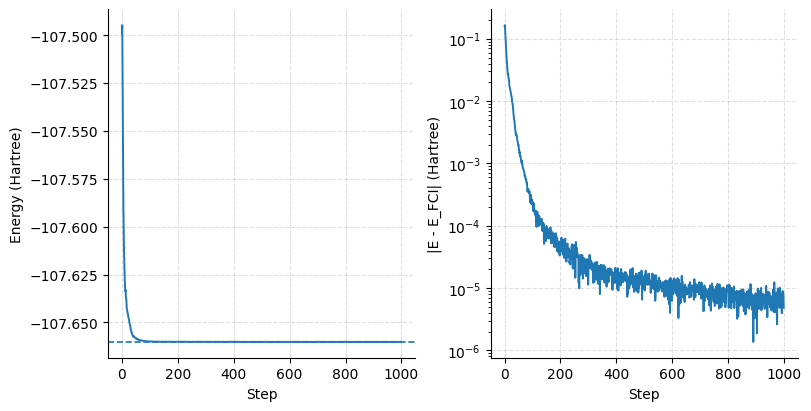

In [5]:
sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    alpha=1.0,
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="hf",
    key=jax.random.key(0),
)

steps = 1000
optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []

for step in range(steps):
    stats = vmc.step()
    history.append(stats['energy'])

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
            f"acc={stats['accept']:.3f}  "
            f"ess={stats['ess']: .1f}  "
            f"ess_unique={stats['ess_unique']: .3f}  "
            f"chain_uratio={stats['chain_uratio']: .3f}  "
            f"sample_uratio={stats['sample_uratio']: .3f}  "
            f"n_eval={stats['n_eval']:}"
        )

        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)

plot_convergence(history, e_fci)
plt.show()